# Credit Card Fraud: Leakage Analysis and Dataset Artifacts
Many fraud detection datasets produce unrealistically high model performance due to synthetic patterns or information leakage. This project investigates whether a high-performing fraud classifier is actually learning meaningful fraud behavior or exploiting dataset artifacts.

### Business problem
Financial institutions need to identify fraudulent transactions while minimizing friction for legitimate customers.

### Approach
- time-based validation
- Logistic Regression baseline
- CatBoost
- feature engineering
- leakage analysis

### Main Result
CatBoost achieves PR-AUC ≈ 0.92, substantially outperforming the baseline. <br>
The exceptional performance is likely explained by synthetic dataset artifacts rather than purely realistic fraud behavior.


## Dataset overview

- Dataset contains 1 296 675 transactions with 23 features
- No missing values
- No duplicate rows
- Target distribution is highly imbalanced, fraud rate - 0.58%

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_palette("Set2")

data_file = '/kaggle/input/fraud-detection/fraudTrain.csv'
df = pd.read_csv(data_file)
print(f"The size of dataset: {df.shape}")

The size of dataset: (1296675, 23)


In [2]:
df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

### Data Quality Checks

In [2]:
# Basic cleaning
df = df.drop(columns=["Unnamed: 0"])

# Parse datetime
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

# Sort by time for time split
df = df.sort_values("trans_date_trans_time").reset_index(drop=True)

In [5]:
missing = df.isna().mean().sort_values(ascending=False)
print(f"Missing cols: {(missing > 0).sum()} / {df.shape[1]}")
print(f"Total missing cells: {df.isna().sum().sum()}")

Missing cols: 0 / 22
Total missing cells: 0


In [6]:
dup_rows = df.duplicated().sum()
dup_trans = df["trans_num"].duplicated().sum()
print(f"Duplicate rows: {dup_rows}")
print(f"Duplicate transaction number: {dup_trans}")

Duplicate rows: 0
Duplicate transaction number: 0


In [7]:
print(f"Time range: [{df['trans_date_trans_time'].min()} : {df['trans_date_trans_time'].max()}]")

Time range: [2019-01-01 00:00:18 : 2020-06-21 12:13:37]


In [8]:
fraud_rate = df['is_fraud'].mean() * 100
print(f"Fraud rate: {fraud_rate:.2f}%")
print(f"Class counts: {df['is_fraud'].value_counts()}")

Fraud rate: 0.58%
Class counts: is_fraud
0    1289169
1       7506
Name: count, dtype: int64


In [9]:
# Unique counts for IDs 
cols_to_check = ["cc_num", "merchant", "category", "city", "state", "job", "gender"]
for col in cols_to_check:
    print(f"{col:10} unique: {df[col].nunique():,}")

cc_num     unique: 983
merchant   unique: 693
category   unique: 14
city       unique: 894
state      unique: 51
job        unique: 494
gender     unique: 2


In [10]:
data_dict = pd.DataFrame({
    "feature": df.columns, 
    "dtype": df.dtypes.astype(str).values,
    "n_unique": [df[c].nunique() for c in df.columns], 
    "missing_rate_%": (df.isna().mean().values * 100).round(3)
})
data_dict = data_dict.sort_values("n_unique", ascending=False).reset_index(drop=True)

In [11]:
# exclude PII fields
pii_cols = ["first", "last", "street", "city", "state", "zip", "dob"]
data_dict["is_pii"] = data_dict["feature"].isin(pii_cols)
display(data_dict)

,feature,dtype,n_unique,missing_rate_%,is_pii
0,trans_num,object,1296675,0.0,False
1,merch_long,float64,1275745,0.0,False
2,unix_time,int64,1274823,0.0,False
3,trans_date_trans_time,datetime64[ns],1274791,0.0,False
4,merch_lat,float64,1247805,0.0,False
5,amt,float64,52928,0.0,False
6,street,object,983,0.0,True
7,cc_num,int64,983,0.0,False
8,zip,int64,970,0.0,True
9,long,float64,969,0.0,False


## EDA
All EDA is performed using the provided training dataset (fraudTrain.csv) only. The official test set (fraudTest.csv) is kept untouched until the final evaluation stage.

- target distribution
- fraud by category
- fraud by hour
- distribution of amount
- category-level fraud rates 

### Feature preparation

In [3]:
df["trans_hour"] = df["trans_date_trans_time"].dt.hour
df["trans_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek # 0 = Mon
df["is_weekend"] = (df["trans_dayofweek"] >= 5).astype(int)

df["age"] = (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25
df["age"] = df["age"].clip(lower=0, upper=120)
df["age"] = df["age"].round(1)

### Target distribution
The dataset is highly imbalanced:
- Legitimate transactions: 99.42%
- Fraudulent transactions: 0.58%

This class imbalance makes accuracy an unreliable evaluation metric. The analysis will therefore focus on Precision, Recall and PR-AUC rather than overall accuracy.

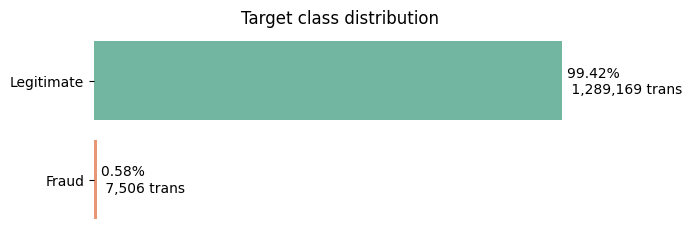

In [13]:
target_distr = (
    df["is_fraud"].value_counts().rename_axis("class").reset_index(name="count")
)
target_distr["class"] = target_distr["class"].map(
    {
        0: "Legitimate",
        1: "Fraud"
    }
)
target_distr["percentage"] = target_distr["count"]/target_distr["count"].sum() * 100

plt.figure(figsize=(7, 2.5))
ax = sns.barplot(data=target_distr, x="percentage", y="class", hue="class", legend=False)

for i, row in target_distr.iterrows():
    ax.text(row["percentage"]+1, i, 
           f'{row["percentage"]:.2f}% \n {row["count"]:,} trans', va='center')

ax.set_title("Target class distribution")
ax.set_xticks([])
ax.set_xlabel("")
ax.set_ylabel("")
sns.despine(left=True, bottom=True)
plt.tight_layout()

### Fraud rate by hour
Fraud rates are substantially higher between 22:00–03:00, while remaining consistently low throughout the rest of the day. This pattern suggests that fraudulent activity is associated with specific transaction times rather than occurring uniformly across the day. <br>
Business implication: Transaction hour is likely to be a valuable predictive feature and should be retained during feature engineering.

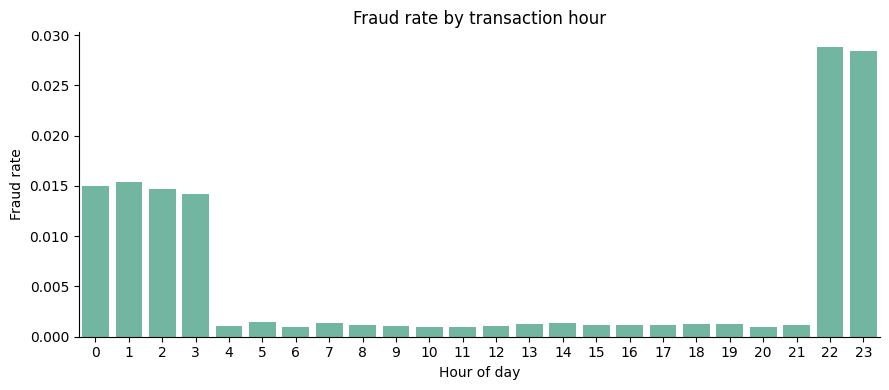

In [4]:
fraud_by_hour = df.groupby("trans_hour")["is_fraud"].mean()

plt.figure(figsize=(9, 4))
sns.barplot(
    x=fraud_by_hour.index, 
    y=fraud_by_hour.values,
)
plt.title("Fraud rate by transaction hour")
plt.xlabel("Hour of day")
plt.ylabel("Fraud rate")
sns.despine()
plt.tight_layout()

### Fraud rate by age
Fraud rates are slightly higher among the youngest and oldest customers, although the effect is considerably weaker than the hour-of-day pattern and should be interpreted with caution.

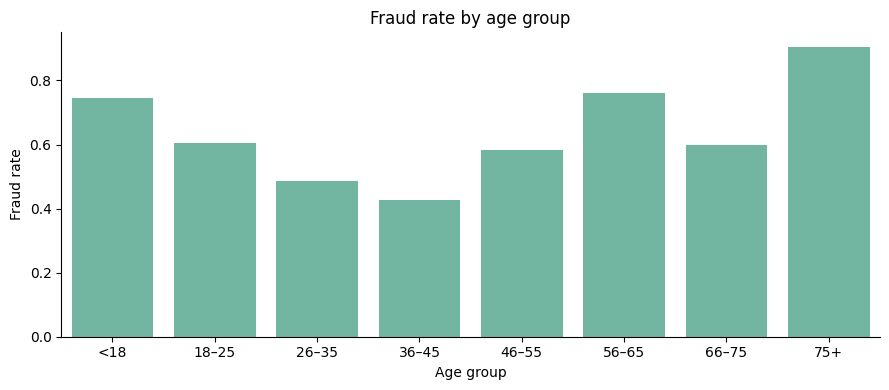

In [5]:
labels = ["<18", "18–25", "26–35", "36–45", "46–55", "56–65", "66–75", "75+"]
age_bins = pd.cut(df["age"], bins=[0, 18, 25, 35, 45, 55, 65, 75, 120], labels=labels)
fraud_by_age = df.groupby(age_bins, observed=True)["is_fraud"].mean() * 100

plt.figure(figsize=(9, 4))
sns.barplot(
    x=fraud_by_age.index, 
    y=fraud_by_age.values)
plt.title("Fraud rate by age group")
plt.xlabel("Age group")
plt.ylabel("Fraud rate")
sns.despine()
plt.tight_layout()
plt.show()

### Transaction amount distribution
Legitimate transactions form a relatively smooth distribution, whereas fraudulent transactions exhibit several sharp peaks at specific amount ranges. Such concentrated patterns are unusual for real-world payment data and may indicate synthetic data generation artifacts rather than natural customer behavior. <br>
Business implication: Models trained on these patterns may achieve unrealistically high performance by exploiting dataset-specific artifacts instead of learning generalizable fraud behavior.


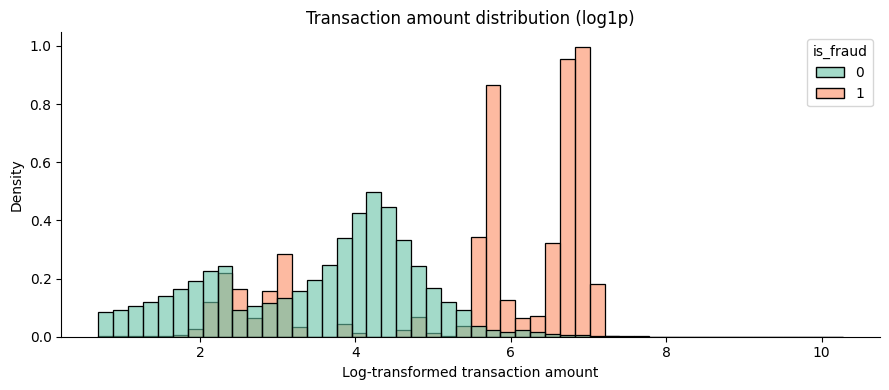

In [16]:
df["log_amt"] = np.log1p(df["amt"])

plt.figure(figsize=(9, 4))
sns.histplot(data=df, x="log_amt", hue="is_fraud", stat="density",
             common_norm=False, bins=50, alpha=0.6)
plt.title("Transaction amount distribution (log1p)")
plt.xlabel("Log-transformed transaction amount")
plt.ylabel("Density")
sns.despine()
plt.tight_layout()

### Fraud rate by category
Fraud rates vary substantially across merchant categories. Online shopping and online miscellaneous merchants exhibit the highest fraud rates, while home, health & fitness, and food & dining show considerably lower risk. The elevated fraud rates for online transactions are consistent with common fraud patterns, where card-not-present payments are generally more vulnerable than in-person purchases.<br>
Business implication: Merchant category should be retained as a core feature in the fraud detection model and may benefit from additional category-level feature engineering.

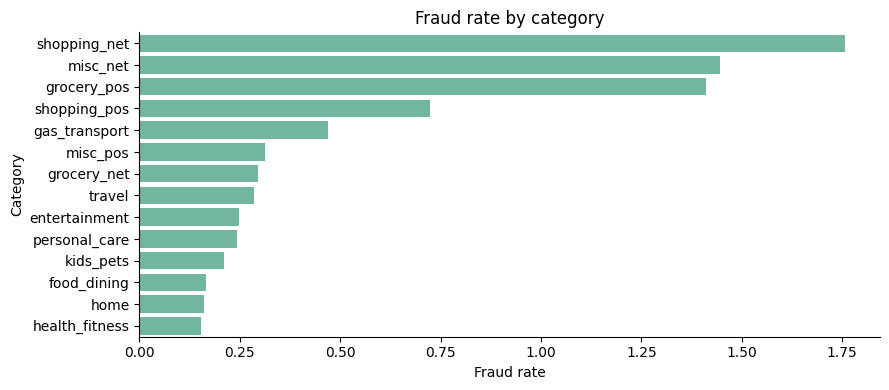

In [6]:
cat_stats = df.groupby("category")["is_fraud"].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=cat_stats.values, y=cat_stats.index)
plt.title("Fraud rate by category")
plt.xlabel("Fraud rate")
plt.ylabel("Category")
sns.despine()
plt.tight_layout()

### Key EDA findings
- The dataset is highly imbalanced (fraud rate: **0.58%**), making accuracy an unsuitable evaluation metric. Model performance will therefore be assessed using **PR-AUC, Precision, Recall, and threshold-based metrics**.
- Fraud activity exhibits a strong temporal pattern, with the highest fraud rates observed during **late-night (22:00–23:00) and early-morning (00:00–03:00)** hours.
- Fraud rates vary across age groups, reaching their lowest level for customers aged **35–45 (0.43%)** and gradually increasing for older customers, peaking at **75+ (0.90%)**.
- Merchant category provides meaningful predictive information: **shopping_net, misc_net, and grocery_pos** show substantially higher fraud rates than other categories, making them valuable candidates for risk segmentation.
- The distribution of transaction amounts differs markedly between fraudulent and legitimate transactions on the **log-transformed scale**, motivating the use of amount-based and velocity-related features.

## Validation strategy
Fraud detection is inherently a temporal prediction problem: future transactions are unavailable at training time. <br>
Random train/test splits may introduce **temporal leakage**, allowing the model to learn patterns that would not be available in a real production environment and leading to overly optimistic evaluation metrics. To better simulate a real-world fraud detection system, the original chronological split provided with the dataset is preserved:
- **Training:** earlier transactions
- **Validation:** last 20% of the training period
- **Testing:** separate chronological test file

This evaluation strategy ensures that every prediction is made using only information available at that point in time.

In [18]:
# split train -> train/valid
y = df["is_fraud"].astype(int)
X = df.drop(columns=["is_fraud"])

# split 80%/20%
split_point = int(len(df) * 0.8)

X_train = X.iloc[:split_point].copy()
y_train = y.iloc[:split_point].copy()

X_valid = X.iloc[split_point:].copy()
y_valid = y.iloc[split_point:].copy()

print(f"Train: {X_train.shape}, Fraud rate: {y_train.mean():.4%}")
print(f"Valid: {X_valid.shape}, Fraud rate:{y_valid.mean():.4%}")

Train: (1037340, 26), Fraud rate: 0.5753%
Valid: (259335, 26), Fraud rate:0.5931%


To avoid temporal leakage, we verified that the provided test split occurs strictly after the training split

In [19]:
test_file = '/kaggle/input/fraud-detection/fraudTest.csv' 
df_test = pd.read_csv(test_file)

df_test["trans_date_trans_time"] = pd.to_datetime(df_test["trans_date_trans_time"], errors="coerce")
df_test = df_test.sort_values("trans_date_trans_time").reset_index(drop=True)

train_max = df["trans_date_trans_time"].max()
test_min = df_test["trans_date_trans_time"].min()

print(f"Train max time: {train_max}")
print(f"Test min time: {test_min}")

Train max time: 2020-06-21 12:13:37
Test min time: 2020-06-21 12:14:25


To confirm the absence of temporal leakage, the timestamps of the provided train and test datasets were compared.

## Baseline model
As a simple and interpretable baseline, a Logistic Regression model is trained using the original features.

The goal is not to maximize predictive performance but to establish a reference point for evaluating the impact of tree-based models and feature engineering.

### Feature selection
Direct identifiers, personal fields, timestamps and very high-cardinality transaction identifiers were removed from the baseline model. The baseline keeps only general transaction, demographic, geographic and time-derived features that could reasonably be available at scoring time.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report, confusion_matrix, precision_recall_curve

# Feature selection
drop_cols = ["trans_date_trans_time", "dob", "first", "last", 
             "street", "city", "zip","trans_num", "unix_time", 
             "merchant", "cc_num"]

X_train_baseline = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_valid_baseline = X_valid.drop(columns=[c for c in drop_cols if c in X_valid.columns])

cat_cols = X_train_baseline.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train_baseline.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols)

Categorical cols: ['category', 'gender', 'state', 'job']
Numeric cols: ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'trans_hour', 'trans_dayofweek', 'is_weekend', 'age', 'log_amt']


In [21]:
preprocess = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), cat_cols)
    ],
    remainder="drop"
)

logreg = LogisticRegression(
    max_iter=2000,  
    class_weight="balanced", 
    n_jobs=-1,
    random_state=42
)

baseline_model = Pipeline(steps=[("preprocess", preprocess), 
                                ("model", logreg)])
baseline_model.fit(X_train_baseline, y_train)
proba_valid = baseline_model.predict_proba(X_valid_baseline)[:,1] # fraud probability

baseline_metrics = {
    "model": "Logistic Regression",
    "PR-AUC": round(average_precision_score(y_valid, proba_valid), 4),
    "ROC-AUC": round(roc_auc_score(y_valid, proba_valid), 4)
}

pd.DataFrame([baseline_metrics])


,model,PR-AUC,ROC-AUC
0,Logistic Regression,0.1154,0.826


### PR-curve

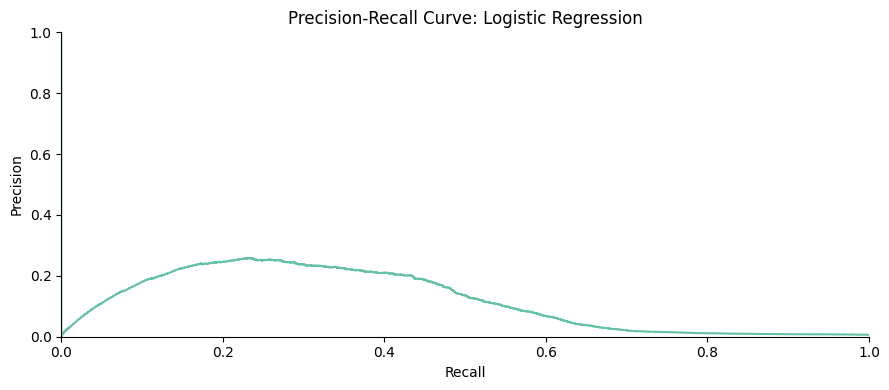

In [22]:
precision, recall, thresholds = precision_recall_curve(y_valid, proba_valid)

plt.figure(figsize=(9, 4))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve: Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
sns.despine()
plt.tight_layout()
plt.show()

In [23]:
def report_at_threshold(y_true, proba, threshold=0.5):
    y_pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    fpr = fp / (fp + tn + 1e-12)
    
    return {
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "fpr": fpr,
        "tp": tp, "fp": fp, "fn":fn, "tn": tn
    }

threshold_results = pd.DataFrame([
    report_at_threshold(y_valid, proba_valid, threshold)
    for threshold in [0.50, 0.20, 0.10, 0.05, 0.02]
])
threshold_results

,threshold,precision,recall,fpr,tp,fp,fn,tn
0,0.50,0.042402,0.637191,0.085850,980,22132,558,235665
1,0.20,0.013533,0.769831,0.334771,1184,86303,354,171494
2,0.10,0.010062,0.835501,0.490378,1285,126418,253,131379
3,0.05,0.008838,0.876463,0.586399,1348,151172,190,106625
4,0.02,0.008201,0.908322,0.655388,1397,168957,141,88840


### Baseline findings
- Logistic Regression achieves **PR-AUC ≈ 0.115** and **ROC-AUC ≈ 0.826** on the chronological validation split.
- Despite capturing a substantial proportion of fraudulent transactions (**Recall ≈ 64%** at the default threshold), precision remains relatively low because of the severe class imbalance and the model's inability to capture complex nonlinear relationships.
- Lowering the decision threshold further increases recall but also leads to a rapid growth in false positives, illustrating the trade-off between fraud detection and operational cost.
- These results motivate the use of more expressive tree-based models together with additional feature engineering to better capture fraud patterns while maintaining a practical precision–recall balance.

### Decision policy simulation
Instead of using a single threshold, many production systems adopt a three-stage policy:
- Approve: low-risk transactions
- Review: medium-risk transactions requiring manual investigation
- Decline: high-risk transactions automatically rejected

In [27]:
# Decision policy
def policy_simulation(proba, y_true, thr_decline=0.5, thr_review=0.5):
    decline = proba >= thr_decline
    review = (proba >= thr_review) & (proba < thr_decline)
    approve = proba < thr_review

    def stats(mask, name):
        n = mask.sum()
        frauds = y_true[mask].sum()
        rate = frauds / (n + 1e-12)
        return {"Segment": name, "Transactions": n, "Fraud Transactions": int(frauds), "Fraud Rate": rate}

    return pd.DataFrame([
        stats(decline, "Decline"), 
        stats(review,  "Review"),
        stats(approve, "Approve")
    ])

result = policy_simulation(proba_valid, y_valid, thr_decline=0.9, thr_review=0.5)
result["Fraud Rate"] = (result["Fraud Rate"] * 100).round(2)
result

,Segment,Transactions,Fraud Transactions,Fraud Rate
0,Decline,2920,613,20.99
1,Review,20192,367,1.82
2,Approve,236223,558,0.24


Using a simple three-stage decision policy substantially concentrates fraud risk.

- **Decline:** only 2,920 transactions are automatically rejected, but they contain a fraud rate of **20.99%**.
- **Review:** manual investigation focuses on transactions with a fraud rate of **1.82%**, approximately three times higher than the overall dataset average.
- **Approve:** the remaining transactions exhibit a fraud rate of only **0.24%**, allowing most customers to pass through with relatively low risk.

Although the Logistic Regression model is relatively simple, its predicted probabilities already provide a meaningful ranking that can be translated into practical business decisions.

## Tree-based model: CatBoost
CatBoost is used as a nonlinear model capable of learning feature interactions without extensive preprocessing.

To isolate the effect of the algorithm itself, the model is trained on exactly the same feature set used for the Logistic Regression baseline, without additional feature engineering.

In [30]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(X_train_baseline, y_train, cat_features=cat_cols)
valid_pool = Pool(X_valid_baseline, y_valid, cat_features=cat_cols)

cb_no_fe = CatBoostClassifier(
    iterations=2000, 
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200
)

cb_no_fe.fit(train_pool, eval_set=valid_pool, use_best_model=True)
proba_valid_cb_no_fe = cb_no_fe.predict_proba(X_valid_baseline)[:, 1]

catboost_metrics = {
    "model": "CatBoost",
    "PR-AUC": round(average_precision_score(y_valid, proba_valid_cb_no_fe), 4),
    "ROC-AUC": round(roc_auc_score(y_valid, proba_valid_cb_no_fe), 4)
}

pd.DataFrame([catboost_metrics])

0:	test: 0.7896948	best: 0.7896948 (0)	total: 766ms	remaining: 25m 31s
200:	test: 0.9943825	best: 0.9943859 (198)	total: 2m 4s	remaining: 18m 38s
400:	test: 0.9965720	best: 0.9965753 (397)	total: 4m 8s	remaining: 16m 30s
600:	test: 0.9970448	best: 0.9970599 (590)	total: 6m 11s	remaining: 14m 24s
800:	test: 0.9973456	best: 0.9973563 (786)	total: 8m 18s	remaining: 12m 26s
1000:	test: 0.9975660	best: 0.9975826 (989)	total: 10m 23s	remaining: 10m 22s
1200:	test: 0.9977694	best: 0.9977701 (1199)	total: 12m 30s	remaining: 8m 19s
1400:	test: 0.9977530	best: 0.9978222 (1313)	total: 14m 49s	remaining: 6m 20s
1600:	test: 0.9976763	best: 0.9978222 (1313)	total: 17m 6s	remaining: 4m 15s
1800:	test: 0.9976168	best: 0.9978222 (1313)	total: 19m 21s	remaining: 2m 8s
1999:	test: 0.9976348	best: 0.9978222 (1313)	total: 21m 36s	remaining: 0us

bestTest = 0.9978222046
bestIteration = 1313

Shrink model to first 1314 iterations.


,model,PR-AUC,ROC-AUC
0,CatBoost,0.9177,0.9978


The CatBoost model achieves a **PR-AUC of approximately 0.92**, representing a substantial improvement over the Logistic Regression baseline (0.115). Such a large performance gain suggests that the model is successfully exploiting complex nonlinear interactions between transaction attributes.

At the same time, unusually high performance on a synthetic fraud dataset raises an important question: **Does the model learn realistic fraud behavior, or does it exploit dataset-specific artifacts and hidden leakage patterns?**

The following sections investigate this hypothesis in detail.

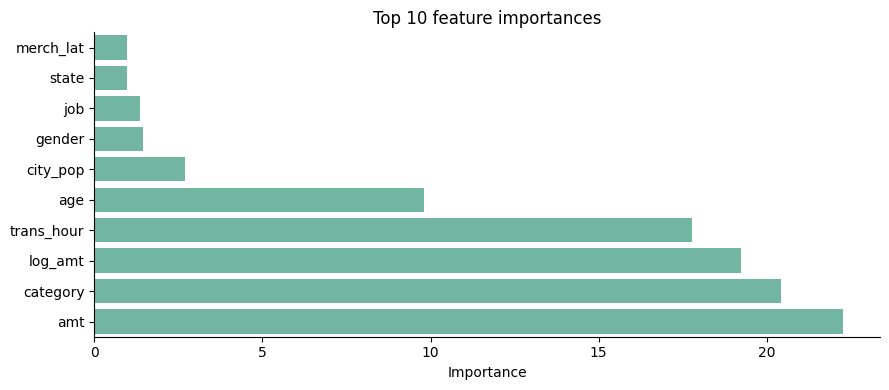

In [33]:
importance = cb_no_fe.get_feature_importance(prettified=True).head(10)

plt.figure(figsize=(9, 4))
sns.barplot(data=importance.sort_values("Importances"),
           x="Importances", y="Feature Id")
plt.title("Top 10 feature importances")
plt.xlabel("Importance")
plt.ylabel("")
sns.despine()
plt.tight_layout()

The most influential features are transaction amount, merchant category, transaction hour and customer age. Interestingly, the ranking closely matches the patterns identified during the exploratory analysis:
- transaction amount and its logarithmic transformation dominate the model,
- merchant category provides strong discriminatory power,
- transaction hour captures the pronounced temporal fraud pattern observed in EDA.

This consistency suggests that CatBoost successfully exploits meaningful nonlinear interactions between these variables. <br>
At the same time, the exceptionally high predictive performance raises the question of whether some of these relationships reflect realistic fraud behavior or synthetic dataset artifacts.

## Feature engineering experiments
Several feature engineering ideas were explored to better approximate production fraud detection systems.The experiments focused on three groups:
- geographic features
- novelty features
- velocity features

The goal was not to maximize benchmark performance, but to understand which features can be safely used without introducing temporal leakage.

### Geo distance between client & merchant

In [ ]:
def haversine_km(lat1, long1, lat2, long2):
    R = 6371.0
    lat1, long1, lat2, long2 = map(np.radians, [lat1, long1, lat2, long2])
    dlat = lat2 - lat1
    dlong = long2 - long1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlong/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

# The following feature ideas are shown for transparency 
# but were intentionally excluded from the final model.
if False:
    df["dist_km"] = haversine_km(df["lat"], df["long"], df["merch_lat"], df["merch_long"]).astype(np.float32)
    df["dist_km"].head(5)

*Geographic distance between customer and merchant was explored as a potential risk signal. It was ultimately excluded from the final model because it provided limited incremental value.*

### Novelty

In [34]:
# The following feature ideas are shown for transparency 
# but were intentionally excluded from the final model
if False:
    df = df.sort_values("trans_date_trans_time").reset_index(drop=True)
    
    df["is_new_merchant_for_card"] = (
    df.groupby("cc_num")["merchant"].transform(lambda s: ~s.duplicated()).astype(int)
)
    df["is_new_category_for_card"] = (
    df.groupby("cc_num")["category"].transform(lambda s: ~s.duplicated()).astype(int)
)
    df[["is_new_merchant_for_card", "is_new_category_for_card"]].head(5)

*Novelty features are computed using only transactions observed before the current event. Therefore, they do not introduce future leakage but require maintaining historical card state in production.*

### Velocity

In [35]:
# The following feature ideas are shown for transparency 
# but were intentionally excluded from the final model
if False:
    df["date"] = df["trans_date_trans_time"].dt.date
    df["hour_bucket"] = df["trans_date_trans_time"].dt.floor("h")
    
    df["card_tx_per_day"] = df.groupby(["cc_num", "date"])["trans_num"].transform("count").astype(np.int32)
    df["card_tx_per_hour"] = df.groupby(["cc_num", "hour_bucket"])["trans_num"].transform("count").astype(np.int32)
    
    df["card_amt_sum_day"] = df.groupby(["cc_num", "date"])["amt"].transform("sum").astype(np.float32)
    df["card_amt_sum_hour"] = df.groupby(["cc_num", "hour_bucket"])["amt"].transform("sum").astype(np.float32)
    
    df[["trans_date_trans_time", "date", "hour_bucket", "card_tx_per_day", "card_tx_per_hour", "card_amt_sum_day", "card_amt_sum_hour"]].head(5)

Several velocity features were initially explored:
- transactions per day
- transactions per hour
- cumulative amount per day
- cumulative amount per hour

*However, these implementations aggregate information over the full day/hour and therefore implicitly include future transactions. As a result, they introduce temporal leakage and were intentionally excluded from the final model.*

### Feature Engineering Findings
Additional handcrafted features provide only marginal improvements over the CatBoost baseline.<br>
This observation suggests that the original dataset already contains highly informative predictive patterns, allowing a nonlinear model to separate fraudulent and legitimate transactions with minimal feature engineering.

Such behavior further motivates the subsequent investigation into dataset artifacts and potential leakage.

## Final conclusions
The objective of this project was not simply to maximize predictive performance, but to investigate how model complexity, feature engineering, and validation strategy affect fraud detection results on a large transaction dataset.

#### Baseline model
A Logistic Regression model was trained using a leakage-safe feature set consisting of transaction amount, merchant category, temporal features, and basic customer attributes.
- PR-AUC = 0.115
- ROC-AUC = 0.826

Despite providing reasonable ranking ability, the linear model struggles with extreme class imbalance and complex feature interactions, making it a realistic production baseline rather than a competitive benchmark.

#### Nonlinear modeling
Replacing Logistic Regression with CatBoost while keeping exactly the same feature set leads to a dramatic improvement
- PR-AUC = 0.92
- ROC-AUC = 0.998

Such a large performance gain indicates that the dataset contains highly informative nonlinear patterns that are easily exploited by tree-based models.

#### Feature engineering and dataset analysis
Several feature engineering ideas were explored, including geographic distance, novelty features, and velocity-based transaction statistics.

These experiments produced only marginal improvements over the CatBoost baseline. Feature importance analysis consistently identified transaction amount, merchant category, and transaction time as the dominant predictive signals, while demographic and geographic variables contributed relatively little.

This suggests that fraud labels in the dataset are primarily determined by a small set of strong synthetic decision rules rather than subtle behavioral patterns.

#### Final takeaway
This project demonstrates that exceptionally high evaluation metrics should always be interpreted with caution. A model can achieve near-perfect benchmark performance while relying on dataset-specific artifacts that may not generalize to real production environments. Consequently, careful validation design, leakage analysis, and critical dataset inspection are just as important as model selection or feature engineering.

Rather than presenting another high-scoring fraud detection model, this project focuses on experimental rigor, reproducibility, and responsible evaluation.

The main conclusion is straightforward: Strong benchmark metrics do not necessarily imply a production-ready fraud detection system. Understanding why a model performs well is often more valuable than achieving the highest score itself.